# 勇者傳說 — Battle Character Generator (T4 GPU)

Generate battle-pose character sprites using **SDXL + pixel-art-xl LoRA** on Colab T4.

| Category | Count | Size | Steps |
|----------|-------|------|-------|
| Party members | 8 | 256×384 | 28 |
| Key NPCs | 4 | 256×384 | 25 |
| Story NPCs | 4 | 256×384 | 25 |

**Output**: `battle_characters/` → 16 RGBA PNGs

## 1. Setup

In [1]:
!pip install -q "numpy<2" scipy
!pip install -q diffusers transformers accelerate safetensors "Pillow>=10,<12" rembg onnxruntime

import gc, json, os, time
from pathlib import Path

try:
    from google.colab import drive
    if not os.path.ismount('/content/drive'):
        drive.mount('/content/drive')
    ON_COLAB = True
except ImportError:
    ON_COLAB = False

GDRIVE_BASE = Path('/content/drive/MyDrive/ai-rpg-game')
OUTPUT_BASE = GDRIVE_BASE / 'outputs' if ON_COLAB else Path('outputs')
MODELS_DIR = GDRIVE_BASE / 'models' if ON_COLAB else Path('models')

for d in [OUTPUT_BASE, MODELS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

import torch
if torch.cuda.is_available():
    name = torch.cuda.get_device_name(0)
    props = torch.cuda.get_device_properties(0)
    vram = (getattr(props, 'total_memory', None) or getattr(props, 'total_mem', 0)) / 1024**3
    DEVICE = 'cuda'
    DTYPE = torch.float16
    print(f'GPU: {name} ({vram:.1f} GB VRAM)')
else:
    DEVICE = 'cpu'
    DTYPE = torch.bfloat16
    print('WARNING: No GPU! Generation will be very slow.')

print(f'Output: {OUTPUT_BASE}')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 66.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
cupy-cuda12x 14.0.1 requires numpy<2.6,>=2.0, but you have numpy 1.26.4 which is incompatible.
shap 0.50.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
tobler 0.13.0 requires numpy>=2.0, but y

## 2. Utilities

In [2]:
class ProgressTracker:
    """Track completed items so we can resume after interruption."""
    def __init__(self, name, base_dir):
        self.path = Path(base_dir) / f'_progress_{name}.json'
        self.done = set()
        if self.path.exists():
            try:
                self.done = set(json.loads(self.path.read_text()))
            except Exception:
                pass

    def is_done(self, key):
        return key in self.done

    def mark_done(self, key):
        self.done.add(key)
        self.path.write_text(json.dumps(sorted(self.done)))

    def summary(self, total):
        return f'{len(self.done)}/{total} done'


def free_vram():
    """Free GPU memory."""
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


def print_vram(label=''):
    """Print current GPU memory usage."""
    if torch.cuda.is_available():
        used = torch.cuda.memory_allocated() / 1024**3
        total = torch.cuda.get_device_properties(0)
        total_gb = (getattr(total, 'total_memory', None) or getattr(total, 'total_mem', 0)) / 1024**3
        print(f'VRAM {label}: {used:.1f} / {total_gb:.1f} GB')
    else:
        print(f'VRAM {label}: N/A (CPU)')

## 3. Prompt Data

In [3]:
PROMPTS = {
    "_meta": {
        "style_prefix_xl": "16-bit JRPG pixel art, Dragonquest style",
        "style_suffix_character_xl": "standing battle stance, 3/4 front view facing lower-right, full body head to boots, single character, clean dark background",
        "negative_prompt_xl": "blurry, text, watermark, signature, multiple characters, duplicate, group, cropped legs, cut off, realistic photo"
    },
    "party": [
        {"name": "char_hero_battle", "prompt_xl": "heroic prince swordsman, gold circlet crown, deep crimson cape flowing, blue plate armor with shoulder pauldrons and gold chest emblem, wielding shining sword, determined expression", "size_w": 256, "size_h": 384, "steps_xl": 28, "guidance_xl": 8.0},
        {"name": "char_elf_battle", "prompt_xl": "elf forest ranger archer, pointed ears, gold circlet, green cloak billowing, dark green leather armor, wielding wooden longbow, alert stance", "size_w": 256, "size_h": 384, "steps_xl": 28, "guidance_xl": 8.0},
        {"name": "char_treant_battle", "prompt_xl": "ancient tree sage wizard, bark-like skin, gold circlet, dark green flowing cape, emerald green robe with nature runes, wielding gnarled wooden staff, wise expression", "size_w": 256, "size_h": 384, "steps_xl": 28, "guidance_xl": 8.0},
        {"name": "char_beast_battle", "prompt_xl": "fierce beast monk martial artist, muscular, red bandana headband, orange tunic, bare powerful fists raised in fighting stance, wild energy aura", "size_w": 256, "size_h": 384, "steps_xl": 28, "guidance_xl": 8.0},
        {"name": "char_merfolk_battle", "prompt_xl": "ocean merfolk priestess healer, elegant, circlet tiara, blue cape flowing, white ornate robe with water motifs, wielding crystal healing staff, serene expression", "size_w": 256, "size_h": 384, "steps_xl": 28, "guidance_xl": 8.0},
        {"name": "char_giant_battle", "prompt_xl": "giant war machine robot warrior, metal helmet, dark blue heavy cape, blue-steel plate armor, wielding massive war hammer, imposing mechanical stance", "size_w": 256, "size_h": 384, "steps_xl": 28, "guidance_xl": 8.0},
        {"name": "char_dwarf_battle", "prompt_xl": "dwarf shadow assassin rogue, hooded, brown cloak concealing, dark leather armor with belts, wielding twin daggers, stealthy crouching pose", "size_w": 256, "size_h": 384, "steps_xl": 28, "guidance_xl": 8.0},
        {"name": "char_undead_battle", "prompt_xl": "undead dark sorcerer mage, pale skin, tall wizard hat, violet flowing cape, purple ornate robe with arcane symbols, wielding dark magic staff, ominous aura", "size_w": 256, "size_h": 384, "steps_xl": 28, "guidance_xl": 8.0}
    ],
    "key_npcs": [
        {"name": "char_npc_shop_battle", "prompt_xl": "friendly merchant shopkeeper, leather apron, coin pouch at belt, warm smile, standing behind invisible counter, holding item", "size_w": 256, "size_h": 384, "steps_xl": 25, "guidance_xl": 7.5},
        {"name": "char_npc_quest_battle", "prompt_xl": "adventurous quest giver, travel-worn cloak, scroll in hand, pointing forward, explorer gear, map tucked in belt", "size_w": 256, "size_h": 384, "steps_xl": 25, "guidance_xl": 7.5},
        {"name": "char_npc_save_battle", "prompt_xl": "holy church priest, white robes with gold trim, prayer beads, gentle expression, hands clasped, divine light", "size_w": 256, "size_h": 384, "steps_xl": 25, "guidance_xl": 7.5},
        {"name": "char_npc_guard_battle", "prompt_xl": "town guard soldier, chain mail armor, iron helmet, spear and shield, standing at attention, protective stance", "size_w": 256, "size_h": 384, "steps_xl": 25, "guidance_xl": 7.5}
    ],
    "story_npcs": [
        {"name": "char_king_battle", "prompt_xl": "regal medieval king, golden crown, royal purple robes with ermine trim, scepter, commanding presence, throne room", "size_w": 256, "size_h": 384, "steps_xl": 25, "guidance_xl": 7.5},
        {"name": "char_demon_lord_battle", "prompt_xl": "demon lord villain, massive curved horns, dark red skin, black spiked armor, flowing dark cape, burning eyes, wielding dark blade, menacing", "size_w": 256, "size_h": 384, "steps_xl": 25, "guidance_xl": 7.5},
        {"name": "char_fallen_guardian_battle", "prompt_xl": "fallen guardian knight, once-noble armor now cracked and corrupted, ghostly blue glow, broken sword, sorrowful expression", "size_w": 256, "size_h": 384, "steps_xl": 25, "guidance_xl": 7.5},
        {"name": "char_dark_knight_battle", "prompt_xl": "enemy dark knight, menacing black full plate armor, red glowing visor, dark greatsword, tattered red cape, evil aura", "size_w": 256, "size_h": 384, "steps_xl": 25, "guidance_xl": 7.5}
    ]
}

## 4. Load SDXL Pipeline + LoRA

In [4]:
from diffusers import StableDiffusionXLPipeline, DPMSolverMultistepScheduler

print_vram('before load')

MODEL_ID = 'stabilityai/stable-diffusion-xl-base-1.0'
LORA_ID = 'nerijs/pixel-art-xl'
LORA_WEIGHT = 0.85  # higher weight for characters (vs 0.8 for monsters)

# --- Check for cached model on Drive ---
cached = MODELS_DIR / 'sdxl-base-fp16'
if cached.exists() and (cached / 'model_index.json').exists():
    print(f'Loading SDXL from cache: {cached}')
    pipe = StableDiffusionXLPipeline.from_pretrained(
        str(cached), torch_dtype=DTYPE, use_safetensors=True)
else:
    print(f'Downloading SDXL from HuggingFace...')
    pipe = StableDiffusionXLPipeline.from_pretrained(
        MODEL_ID, torch_dtype=DTYPE, use_safetensors=True,
        variant='fp16')
    # Cache to Drive for future runs (non-fatal if it fails)
    if ON_COLAB:
        try:
            print(f'Caching to Drive: {cached}')
            pipe.save_pretrained(str(cached))
        except Exception as e:
            print(f'[warn] Drive cache failed (non-fatal): {e}')

# --- Scheduler: DPM++ 2M Karras ---
pipe.scheduler = DPMSolverMultistepScheduler.from_config(
    pipe.scheduler.config,
    algorithm_type='dpmsolver++',
    use_karras_sigmas=True)

# --- LoRA ---
print(f'Loading LoRA: {LORA_ID} (weight={LORA_WEIGHT})')
pipe.load_lora_weights(LORA_ID)
pipe.fuse_lora(lora_scale=LORA_WEIGHT)

pipe = pipe.to(DEVICE)
pipe.enable_attention_slicing()

print_vram('after load')
print('Pipeline ready!')

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


VRAM before load: 0.0 / 14.6 GB


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/609 [00:00<?, ?B/s]

Fetching 19 files:   0%|          | 0/19 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Loading LoRA: nerijs/pixel-art-xl (weight=0.85)


pixel-art-xl.safetensors:   0%|          | 0.00/171M [00:00<?, ?B/s]

No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new
No LoRA keys associated to CLIPTextModelWithProjection found with the prefix='text_encoder_2'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModelWithProjection related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new


VRAM after load: 6.7 / 14.6 GB
Pipeline ready!


## 5. Background Removal + Post-Processing

In [5]:
from PIL import Image

_rembg_session = None

def remove_background(image):
    global _rembg_session
    try:
        from rembg import remove, new_session
        if _rembg_session is None:
            _rembg_session = new_session('u2net')
        return remove(image, session=_rembg_session)
    except Exception:
        print('[warn] No background removal available')
        return image.convert('RGBA')


def build_prompt(entry, meta, category):
    prompt = entry.get('prompt_xl', entry.get('prompt', ''))
    prefix = meta.get('style_prefix_xl', '')
    suffix = meta.get('style_suffix_character_xl', '')
    if prefix:
        prompt = f'{prefix}, {prompt}'
    if suffix:
        prompt = f'{prompt}, {suffix}'
    neg = entry.get('negative_prompt', meta.get('negative_prompt_xl', ''))
    return prompt, neg


def postprocess(image, entry, category, do_rembg=True):
    target_w = entry.get('size_w', 256)
    target_h = entry.get('size_h', 384)
    if do_rembg:
        image = remove_background(image)
    if image.mode == 'RGBA':
        bbox = image.getbbox()
        if bbox:
            image = image.crop(bbox)
    # Resize to fit target maintaining aspect ratio
    w, h = image.size
    scale = min(target_w / w, target_h / h)
    nw, nh = int(w * scale), int(h * scale)
    image = image.resize((nw, nh), Image.NEAREST)
    # Center on transparent canvas (bottom-aligned)
    canvas = Image.new('RGBA', (target_w, target_h), (0, 0, 0, 0))
    canvas.paste(image, ((target_w - nw) // 2, target_h - nh),
                 image if image.mode == 'RGBA' else None)
    return canvas


def generate_one(entry, meta, category, out_dir, tracker):
    name = entry['name']
    out_path = out_dir / f'{name}.png'

    if tracker.is_done(name) and out_path.exists():
        print(f'  [skip] {name}')
        return False

    prompt, neg = build_prompt(entry, meta, category)
    steps = entry.get('steps_xl', 28)
    guidance = entry.get('guidance_xl', 8.0)

    # Character aspect ratio: 512x768
    print(f'  [gen] {name} (512x768, {steps} steps)')
    t0 = time.time()

    result = pipe(
        prompt=prompt, negative_prompt=neg,
        width=512, height=768,
        num_inference_steps=steps, guidance_scale=guidance,
    )
    image = result.images[0]
    image = postprocess(image, entry, category)
    image.save(str(out_path), 'PNG')

    kb = out_path.stat().st_size / 1024
    print(f'        saved: {name}.png ({kb:.0f} KB, {time.time()-t0:.1f}s)')
    tracker.mark_done(name)
    free_vram()
    return True

## 6. Test: Generate 1 Character

Token indices sequence length is longer than the specified maximum sequence length for this model (78 > 77). Running this sequence through the model will result in indexing errors


Prompt: 16-bit JRPG pixel art, Dragonquest style, heroic prince swordsman, gold circlet crown, deep crimson cape flowing, blue p...


The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['background']
Token indices sequence length is longer than the specified maximum sequence length for this model (78 > 77). Running this sequence through the model will result in indexing errors
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['background']


  0%|          | 0/28 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(


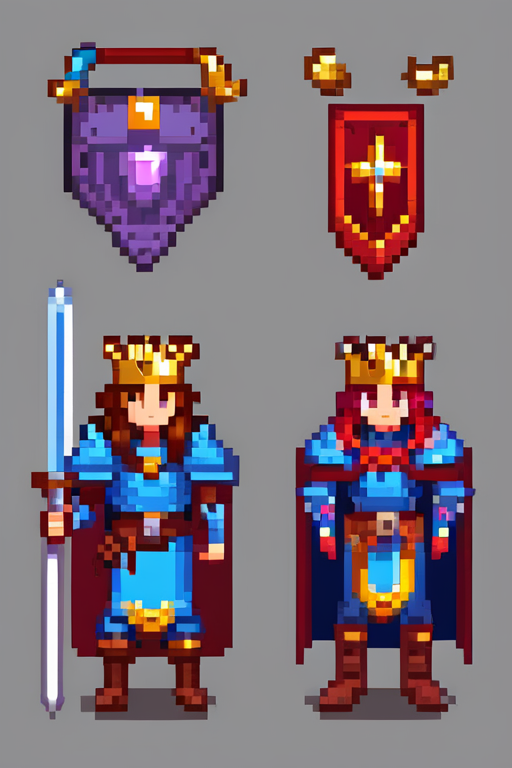

  0%|                                               | 0.00/176M [00:00<?, ?B/s]

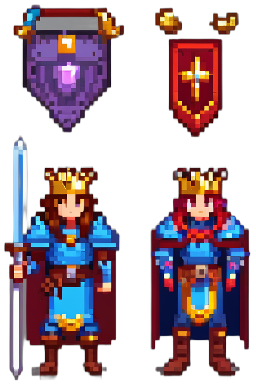

In [6]:
from IPython.display import display

meta = PROMPTS['_meta']
test_entry = PROMPTS['party'][0]
prompt, neg = build_prompt(test_entry, meta, 'party')
print(f'Prompt: {prompt[:120]}...')

result = pipe(prompt=prompt, negative_prompt=neg, width=512, height=768,
              num_inference_steps=28, guidance_scale=8.0)
display(result.images[0])
test_img = postprocess(result.images[0], test_entry, 'party')
display(test_img)
free_vram()

## 7. Generate Party Members (8 sprites)

~8-10s per character on T4

In [7]:
entries = PROMPTS['party']
meta = PROMPTS['_meta']
out_dir = OUTPUT_BASE / 'battle_characters'
out_dir.mkdir(parents=True, exist_ok=True)

tracker = ProgressTracker('battle_chars_party', OUTPUT_BASE)
remaining = sum(1 for e in entries if not tracker.is_done(e['name']))
print(f'\nParty: {len(entries)} total, {remaining} to generate')

for i, entry in enumerate(entries):
    print(f'\n[{i+1}/{len(entries)}] {tracker.summary(len(entries))}')
    generate_one(entry, meta, 'party', out_dir, tracker)

print(f'\nDone!')

The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['background']
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['background']



Party: 8 total, 8 to generate

[1/8] 0/8 done
  [gen] char_hero_battle (512x768, 28 steps)


  0%|          | 0/28 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(


        saved: char_hero_battle.png (59 KB, 12.7s)

[2/8] 1/8 done
  [gen] char_elf_battle (512x768, 28 steps)


...

        saved: char_giant_battle.png (98 KB, 15.4s)

[7/8] 6/8 done
  [gen] char_dwarf_battle (512x768, 28 steps)


  0%|          | 0/28 [00:00<?, ?it/s]

        saved: char_dwarf_battle.png (39 KB, 15.3s)

[8/8] 7/8 done
  [gen] char_undead_battle (512x768, 28 steps)


  0%|          | 0/28 [00:00<?, ?it/s]

        saved: char_undead_battle.png (86 KB, 14.7s)

Done!


## 8. Generate Key NPCs (4 sprites)

In [8]:
entries = PROMPTS['key_npcs']
meta = PROMPTS['_meta']
out_dir = OUTPUT_BASE / 'battle_characters'
out_dir.mkdir(parents=True, exist_ok=True)

tracker = ProgressTracker('battle_chars_npcs', OUTPUT_BASE)
remaining = sum(1 for e in entries if not tracker.is_done(e['name']))
print(f'\nKey NPCs: {len(entries)} total, {remaining} to generate')

for i, entry in enumerate(entries):
    print(f'\n[{i+1}/{len(entries)}] {tracker.summary(len(entries))}')
    generate_one(entry, meta, 'key_npcs', out_dir, tracker)

print(f'\nDone!')


Key NPCs: 4 total, 4 to generate

[1/4] 0/4 done
  [gen] char_npc_shop_battle (512x768, 25 steps)


  0%|          | 0/25 [00:00<?, ?it/s]

        saved: char_npc_shop_battle.png (86 KB, 13.2s)

[2/4] 1/4 done
  [gen] char_npc_quest_battle (512x768, 25 steps)


  0%|          | 0/25 [00:00<?, ?it/s]

        saved: char_npc_quest_battle.png (93 KB, 13.3s)

[3/4] 2/4 done
  [gen] char_npc_save_battle (512x768, 25 steps)


  0%|          | 0/25 [00:00<?, ?it/s]

        saved: char_npc_save_battle.png (88 KB, 14.8s)

[4/4] 3/4 done
  [gen] char_npc_guard_battle (512x768, 25 steps)


  0%|          | 0/25 [00:00<?, ?it/s]

        saved: char_npc_guard_battle.png (93 KB, 13.9s)

Done!


## 9. Generate Story NPCs (4 sprites)

In [ ]:
entries = PROMPTS['story_npcs']
meta = PROMPTS['_meta']
out_dir = OUTPUT_BASE / 'battle_characters'
out_dir.mkdir(parents=True, exist_ok=True)

tracker = ProgressTracker('battle_chars_story', OUTPUT_BASE)
remaining = sum(1 for e in entries if not tracker.is_done(e['name']))
print(f'\nStory NPCs: {len(entries)} total, {remaining} to generate')

for i, entry in enumerate(entries):
    print(f'\n[{i+1}/{len(entries)}] {tracker.summary(len(entries))}')
    generate_one(entry, meta, 'story_npcs', out_dir, tracker)

print(f'\nDone!')


Story NPCs: 4 total, 4 to generate

[1/4] 0/4 done
  [gen] char_king_battle (512x768, 25 steps)


  0%|          | 0/25 [00:00<?, ?it/s]

        saved: char_king_battle.png (95 KB, 13.7s)

[2/4] 1/4 done
  [gen] char_demon_lord_battle (512x768, 25 steps)


  0%|          | 0/25 [00:00<?, ?it/s]

        saved: char_demon_lord_battle.png (79 KB, 13.5s)

[3/4] 2/4 done
  [gen] char_fallen_guardian_battle (512x768, 25 steps)


  0%|          | 0/25 [00:00<?, ?it/s]

        saved: char_fallen_guardian_battle.png (91 KB, 13.4s)

[4/4] 3/4 done
  [gen] char_dark_knight_battle (512x768, 25 steps)


  0%|          | 0/25 [00:00<?, ?it/s]

## 10. Quality Review — Battle Mockup

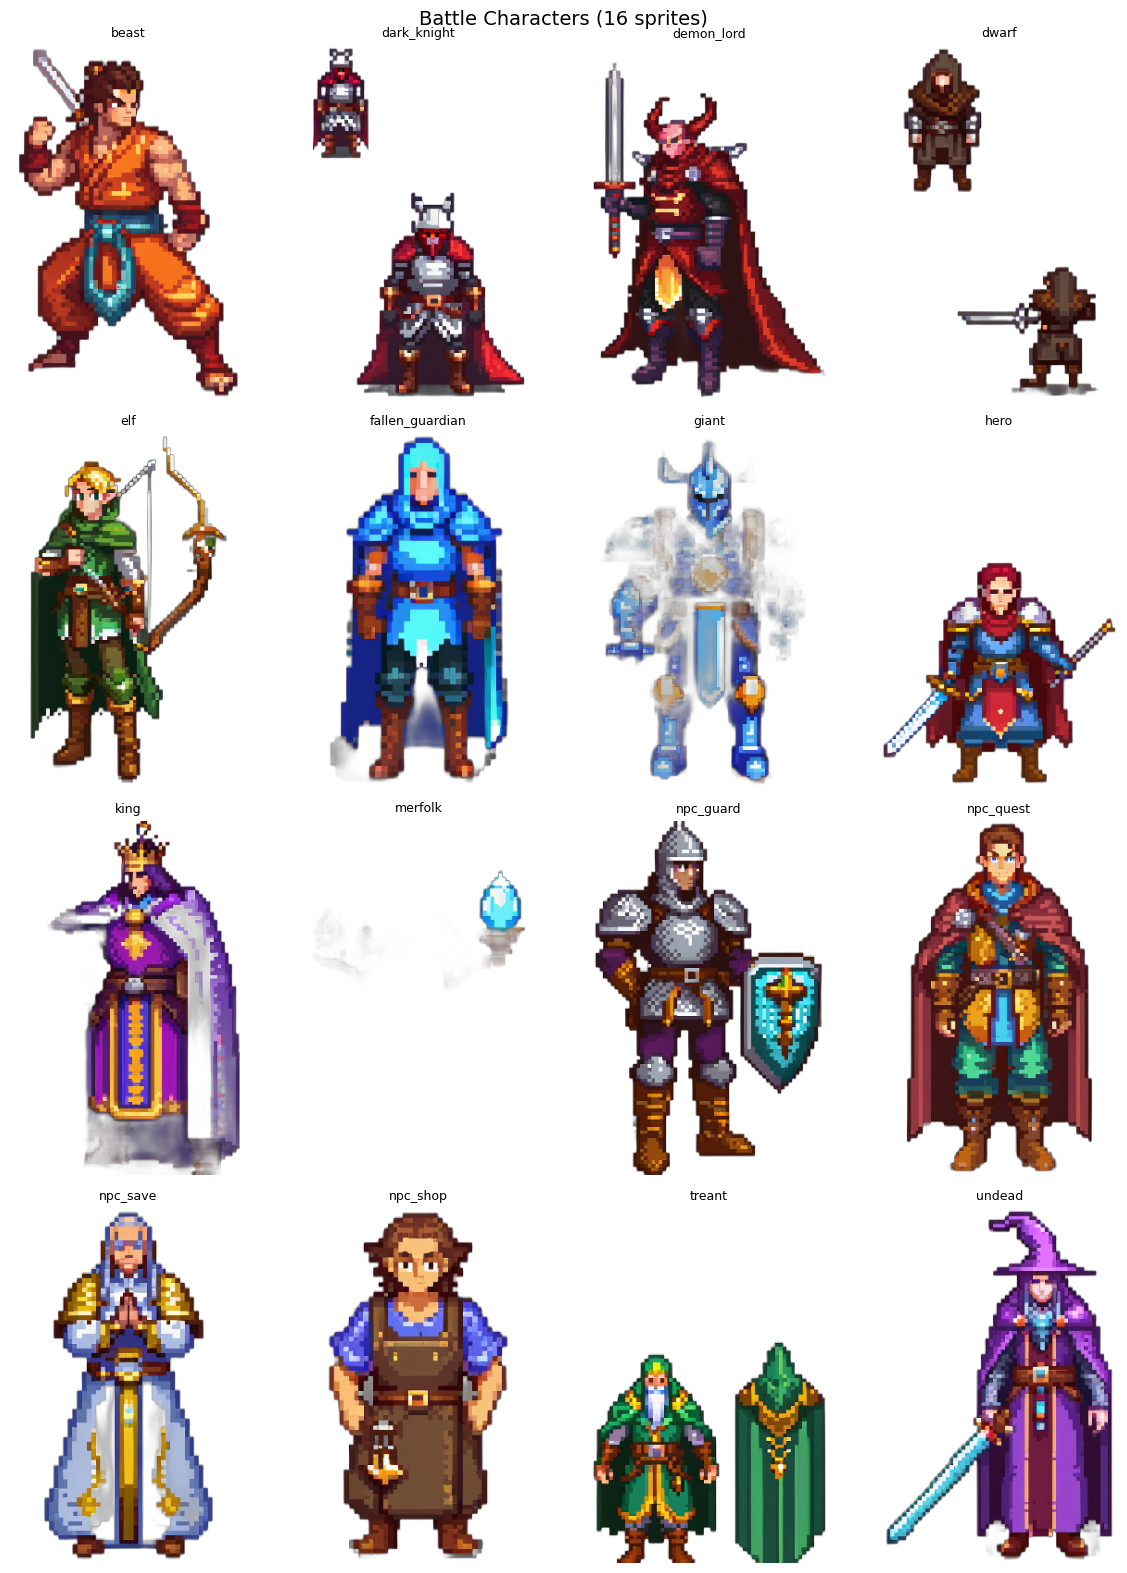

In [ ]:
import matplotlib.pyplot as plt

out_dir = OUTPUT_BASE / 'battle_characters'
pngs = sorted(out_dir.glob('*.png'))
pngs = [p for p in pngs if not p.stem.startswith('_')]

cols = 4
rows = (len(pngs) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 4))
for ax in axes.flat:
    ax.axis('off')

for i, png in enumerate(pngs):
    ax = axes[i // cols][i % cols] if rows > 1 else axes[i % cols]
    img = Image.open(png)
    ax.imshow(img)
    ax.set_title(png.stem.replace('char_', '').replace('_battle', ''), fontsize=9)

plt.suptitle(f'Battle Characters ({len(pngs)} sprites)', fontsize=14)
plt.tight_layout()
plt.show()

## 11. Generate Manifest + Download

In [ ]:
import shutil

manifest = {}
d = OUTPUT_BASE / 'battle_characters'
if d.exists():
    keys = sorted(f.stem for f in d.glob('*.png') if not f.stem.startswith('_'))
    if keys:
        manifest['battle_characters'] = keys

manifest_path = OUTPUT_BASE / 'manifest.json'
with open(manifest_path, 'w', encoding='utf-8') as f:
    json.dump(manifest, f, indent=2)

print('Manifest:')
for cat, keys in manifest.items():
    print(f'  {cat}: {len(keys)}')

zip_path = '/content/characters_output'
shutil.make_archive(zip_path, 'zip', str(OUTPUT_BASE))
print(f'\nZip: {os.path.getsize(zip_path + ".zip") / 1024 / 1024:.1f} MB')

if ON_COLAB:
    from google.colab import files
    files.download(f'{zip_path}.zip')
else:
    print(f'Download: {zip_path}.zip')